In [1]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import Subset

from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns
from random import randrange
import math

In [2]:
tensor = torch.tensor([1, 2, 3, 4], dtype=torch.float32)
tensor[1:3] = torch.tensor([1, 2])
print(tensor)

loss = nn.NLLLoss()
loss2 = nn.CrossEntropyLoss()
print(loss2(tensor, torch.tensor(3)))

tensor = torch.softmax(tensor, dim=0)
print(loss(torch.log(tensor), torch.tensor(3)))

tensor([1., 1., 2., 4.])
tensor(0.2110)
tensor(0.2110)


In [3]:
"""SEED = 69

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)"""

'SEED = 69\n\nnp.random.seed(SEED)\ntorch.manual_seed(SEED)\ntorch.cuda.manual_seed_all(SEED)'

## **Hyperparameters**

In [4]:
BATCH_SIZE = 64
LEARNING_RATE = 1e-4
VALIDATION_SPLIT = 0.2

## **Data loading**

In [5]:
NUM_CLASSES = 6
NUM_SUBJECTS = 30
NUM_CHANNELS = 9

TRAINING_SUBJECTS = 21


activity_labels = {
    0: "WALKING",
    1: "WALKING_UPSTAIRS",
    2: "WALKING_DOWNSTAIRS",
    3: "SITTING",
    4: "STANDING",
    5: "LAYING"
}

data_path = {
    "train": "../data/UCI-HAR/train/",
    "test": "../data/UCI-HAR/test/"
}

signals_path = [
    "body_acc_x", "body_acc_y", "body_acc_z",
    "body_gyro_x", "body_gyro_y", "body_gyro_z",
    "total_acc_x", "total_acc_y", "total_acc_z"
]


def split_for_validation (train_dataset):
    val_subjects_split = math.floor(VALIDATION_SPLIT * TRAINING_SUBJECTS)
    train_subjects_split = TRAINING_SUBJECTS - val_subjects_split
    train_subjects = np.loadtxt(data_path["train"] + "subject_train.txt").astype("int")

    counter = 0
    curr_subj = 0
    val_split_start = 0
    for subj in train_subjects:
        val_split_start += 1
        if subj != curr_subj:
            curr_subj = subj
            counter += 1
        if counter == train_subjects_split + 1:
            break

    train_subset = Subset(train_dataset, [i for i in range(0, val_split_start)])
    validation_subset = Subset(train_dataset, [i for i in range (val_split_start, train_dataset.__len__())])

    return (train_subset, validation_subset)


class HARDataset (Dataset):
    def __init__ (self, type):
        self.labels = np.loadtxt(data_path[type] + "y_" + type + ".txt").astype("int")
        self.subjects = np.loadtxt(data_path[type] + "subject_" + type + ".txt").astype("int")

        for idx in range(0, len(signals_path)):
            signals = np.loadtxt(data_path[type] + "Inertial Signals/" + signals_path[idx] + "_" + type + ".txt").astype("float32")
            if idx > 0:
                self.data = np.dstack((self.data, signals))
            else:
                self.data = signals

    def __len__ (self):
        return len(self.labels)

    def __getitem__ (self, idx):
        # item: [128, 9]
        item = self.data[idx, :, :]
        item = np.transpose(item)
        label = torch.tensor(self.labels[idx] - 1, dtype=torch.long)

        return item, label
    

train_dataset = HARDataset("train")

train_subset, validation_subset = split_for_validation(train_dataset)
train_dataloader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
validation_dataloader = DataLoader(validation_subset, batch_size=1, shuffle=False)

test_dataset = HARDataset("test")
test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False)

## **Data stats and plottings**

PREVIOUS ACTIVITY: WALKING_UPSTAIRS
CURRENT ACTIVITY: WALKING_UPSTAIRS
NEXT ACTIVITY: WALKING_UPSTAIRS
Related concepts: ['Dynamic', 'Vertical-upright posture', 'Medium energy']


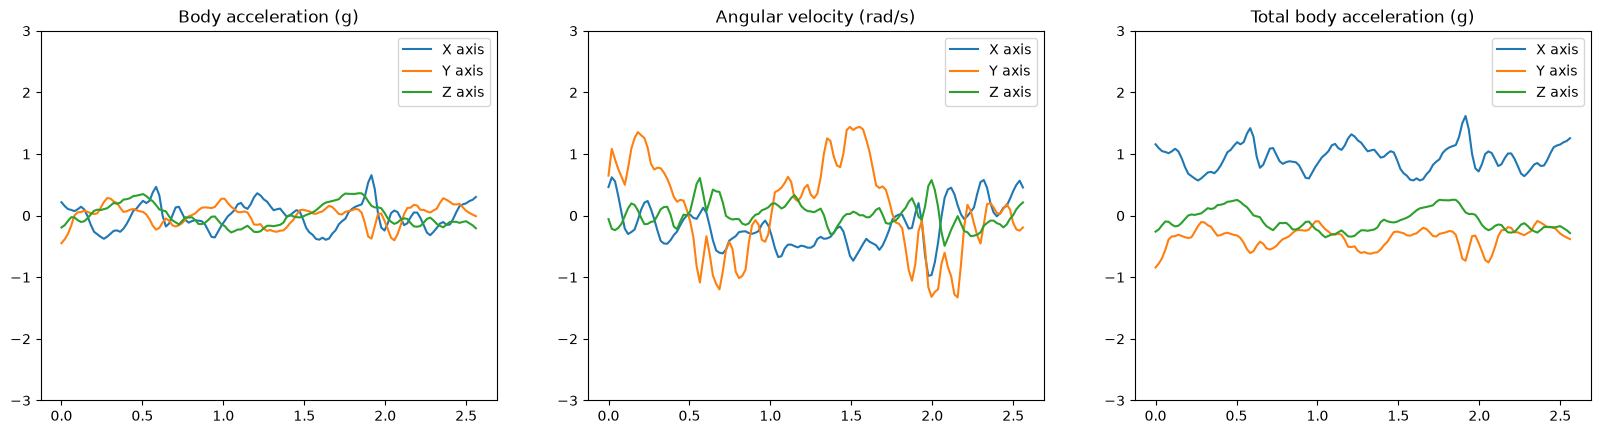

In [6]:
TRAIN_SAMPLES = train_dataset.__len__()
TEST_SAMPLES = test_dataset.__len__()

type = "train"
concepts = np.loadtxt(data_path[type] + "concepts_" + type + ".txt").astype("float32")

x = np.linspace(0, 2.56, 128)

# Getting a random sample from the training dataset
rand_idx = randrange(TRAIN_SAMPLES)
item = (train_dataset.__getitem__(rand_idx))
y = item[0]

# Getting the activity related to that sample
activity_idx = item[1].item()
activity = activity_labels[activity_idx]

# Getting the subject related to that sample
subject = train_dataset.subjects[rand_idx].item()


# Printing the activity carried out in the previous timestep (if related to the same subject)
if rand_idx > 0:
    prev_activity_idx = (train_dataset.__getitem__(rand_idx - 1))[1].item()
    prev_subject = train_dataset.subjects[rand_idx - 1].item()
    if prev_subject == subject:
        print("PREVIOUS ACTIVITY:", activity_labels[prev_activity_idx])

print("CURRENT ACTIVITY:", activity)

# Printing the activity carried out in the next timestep (if related to the same subject)
if rand_idx < TRAIN_SAMPLES - 1:
    next_activity_idx = (train_dataset.__getitem__(rand_idx + 1))[1].item()
    next_subject = train_dataset.subjects[rand_idx + 1].item()
    if next_subject == subject:
        print("NEXT ACTIVITY:", activity_labels[next_activity_idx])

rel_c = list()
if concepts[rand_idx][0] == 0:
    rel_c.append("Static")
else:
    rel_c.append("Dynamic")
if concepts[rand_idx][1] == 1 and concepts[rand_idx][2] == 0 and concepts[rand_idx][3] == 0:
    rel_c.append("Horizontal posture")
elif concepts[rand_idx][1] == 0 and concepts[rand_idx][2] == 1 and concepts[rand_idx][3] == 0:
    rel_c.append("Vertical-upright posture")
else:
    rel_c.append("Vertical-tilted posture")
if concepts[rand_idx][4] == 1 and concepts[rand_idx][5] == 0 and concepts[rand_idx][6] == 0:
    rel_c.append("Low energy")
elif concepts[rand_idx][4] == 0 and concepts[rand_idx][5] == 1 and concepts[rand_idx][6] == 0:
    rel_c.append("Medium energy")
else:
    rel_c.append("High energy")
print("Related concepts:", rel_c)
# Plotting the acceleration and angular velocity related to the chosen sample
fig, ax = plt.subplots(1, 3)
fig.set_figwidth(20)
for i in range(0, NUM_CHANNELS, 3):
    if i == 0: ax[int(i / 3)].set_title("Body acceleration (g)")
    if i == 3: ax[int(i / 3)].set_title("Angular velocity (rad/s)")
    if i == 6: ax[int(i / 3)].set_title("Total body acceleration (g)")

    ax[int(i / 3)].plot(x, y[i], label="X axis")
    ax[int(i / 3)].plot(x, y[i + 1], label="Y axis")
    ax[int(i / 3)].plot(x, y[i + 2], label="Z axis")
    ax[int(i / 3)].legend()
    plt.setp(ax, ylim=[-3, 3])
plt.show()

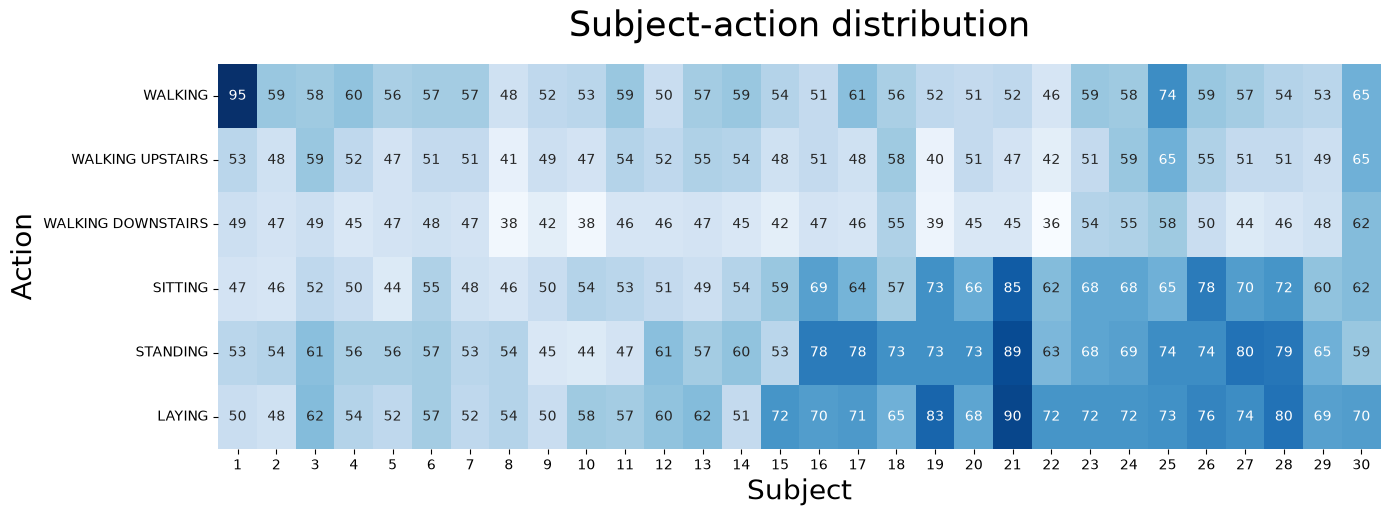

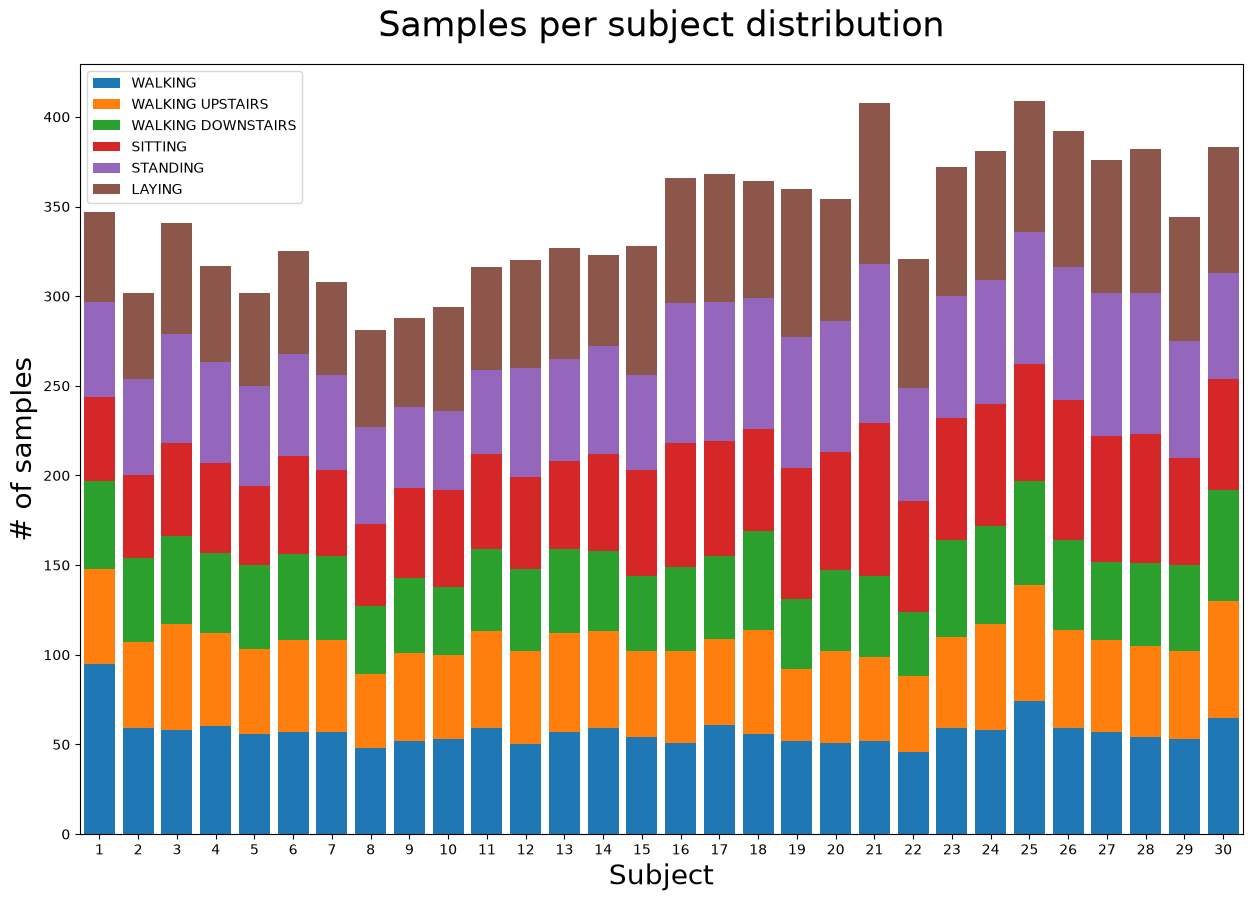

In [7]:
plot_stats_1 = np.zeros((NUM_CLASSES, NUM_SUBJECTS))

for i in range(0, train_dataset.__len__()):
    activity = train_dataset.labels[i] - 1
    subject = train_dataset.subjects[i] - 1
    plot_stats_1[activity][subject] += 1

for i in range(0, test_dataset.__len__()):
    activity = test_dataset.labels[i] - 1
    subject = test_dataset.subjects[i] - 1
    plot_stats_1[activity][subject] += 1


xlabels = [i for i in range(1, NUM_SUBJECTS + 1)]
ylabels = ["WALKING", "WALKING UPSTAIRS", "WALKING DOWNSTAIRS", "SITTING", "STANDING", "LAYING"]

plt.figure(figsize=(15, 5))
sns.heatmap(plot_stats_1, annot=True, cmap="Blues", fmt="g", cbar=False, xticklabels=xlabels, yticklabels=ylabels)
plt.title("Subject-action distribution", fontsize=25, pad=20)
plt.xlabel("Subject", fontsize=20)
plt.ylabel("Action", fontsize=20)
plt.show()


plot_stats_2 = plot_stats_1.sum(axis=0).astype("int")

x = [i for i in range(0, NUM_SUBJECTS)]
plt.figure(figsize=(15, 10))
plt.xticks(xlabels)
plt.xlim(xmin=0.5, xmax=30.5)
bottom = 0

for i in range(0, NUM_CLASSES):
    plt.bar(xlabels, plot_stats_1[i], bottom=bottom, label=ylabels[i])
    bottom += plot_stats_1[i]

plt.title("Samples per subject distribution", fontsize=25, pad=20)
plt.xlabel("Subject", fontsize=20)
plt.ylabel("# of samples", fontsize=20)
plt.legend()
plt.show()

## **Model testing**

In [ ]:
"""model = BaselineModel(NUM_CLASSES)
model.load_state_dict(torch.load("../model/weights.pt", weights_only=True))
model.eval()


stats = dict()
test_loss = 0

for i, data in enumerate(test_dataloader):
    inputs, labels = data
    outputs = model(inputs)

    loss = criterion(outputs, labels)
    test_loss += loss.item()

    subj_idx = int(test_dataset.subjects[i])
    if subj_idx not in stats:
        stats[subj_idx] = [0, 0]
    
    stats[subj_idx][0] += batch_accuracy(outputs, labels)
    stats[subj_idx][1] += 1

test_loss = round(test_loss / len(test_dataloader), 4)
test_acc = evaluate(model, test_dataloader)

print("Test loss:", test_loss)
print("Test accuracy:", str(test_acc) + "%")

plot_conf_matrix(model, test_dataloader, title="Confusion matrix related to the test set")


acc_per_subj = np.zeros((NUM_SUBJECTS - TRAINING_SUBJECTS,))
idx = 0
for subj_idx in stats:
    acc_per_subj[idx] = round(stats[subj_idx][0] / stats[subj_idx][1], 3)
    idx += 1

x = list(map(str, list(stats.keys())))
plt.figure(figsize=(10, 5))
bars = plt.bar(x, acc_per_subj)
plt.bar_label(bars)

plt.xlabel("Subject", fontsize=15)
plt.ylabel("Accuracy", fontsize=15)
plt.show()"""